In [1]:
import numpy as np
import xarray as xr
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import matplotlib.path as mpath
import xarray.ufuncs as xu
import gsw

In [18]:
pip install xarray

Note: you may need to restart the kernel to use updated packages.


# Creating South Polar Stereo Projection Map with CbPM NPP

In [4]:
# cbpm = xr.open_dataset('/Users/steviewalker/Documents/Bloom_Raiders/Data/satellite_data/MODIS.L3m_8D_cbpm2_1080x2160_subset_entire_SO.nc')['npp'].max(dim = 'time')/100#convert to gC / m2/ yr
# cbpm
cbpm = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/MODIS.L3m_8D_cbpm2_1080x2160_subset_entire_SO.nc')['npp'].max(dim = 'time')/100#convert to gC / m2/ yr
cbpm

OSError: [Errno -101] NetCDF: HDF error: '/Users/lilah/Documents/IBIS_Project/Data/satellite_data/MODIS.L3m_8D_cbpm2_1080x2160_subset_entire_SO.nc'

NameError: name 'cbpm' is not defined

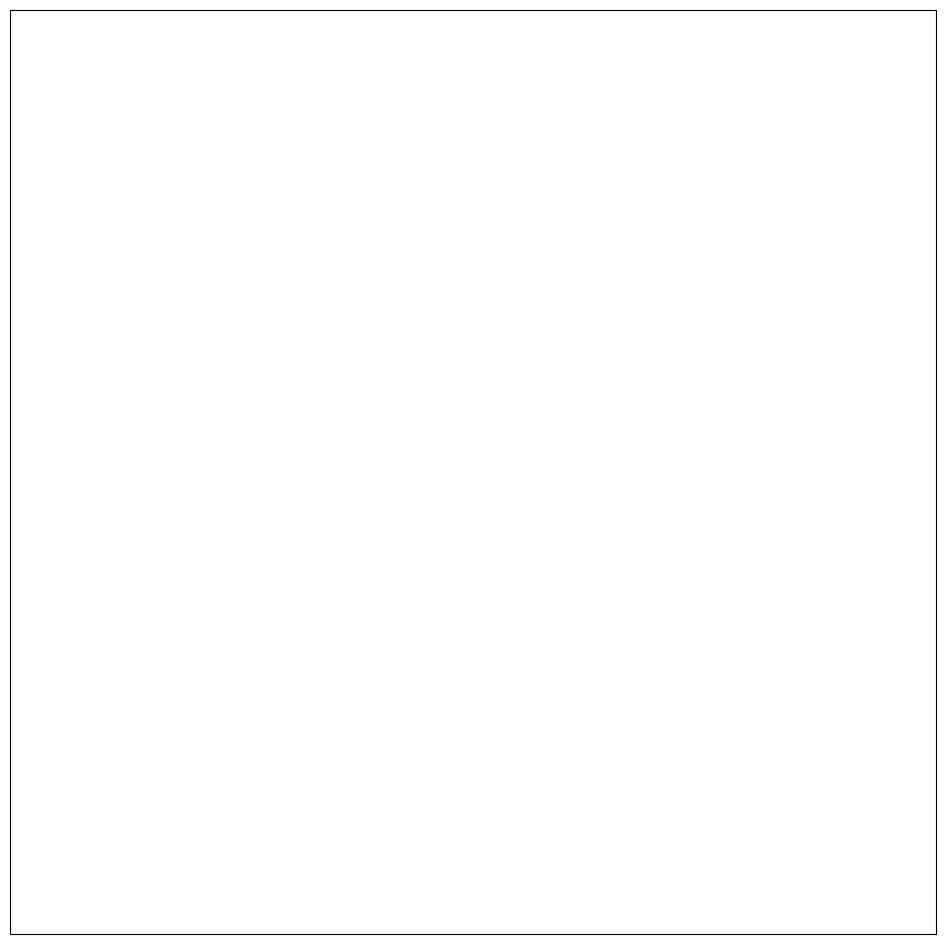

In [11]:
axis_size = 16
tick_size = 14
title_size = 25
vmin = 0
vmax = 12
cmap = cmocean.cm.haline
colorbar_label = r'NPP (gC/m$^2$/yr)'
fig = plt.figure(figsize=(12,12))

crs0 = ccrs.PlateCarree()
crs = ccrs.SouthPolarStereo(central_longitude=120)
theta = np.linspace(0, 2*np.pi, 100)
map_circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])

ax = fig.add_subplot(111, projection=crs)
ax.set_extent([-180, 180, -90, -40], crs=ccrs.PlateCarree())

#add chla data here when ready
plot = cbpm.plot(cmap=cmap, transform=crs0,
                      x='lon', y='lat', vmin=vmin, vmax=vmax, add_colorbar=False)

coast_50m = cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor='darkgray')
ax.add_feature(coast_50m)
ax.set_boundary(map_circle, transform=ax.transAxes)

cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=tick_size)
cbar.set_label(colorbar_label, size=axis_size)

gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                  linewidth=1, color='grey', alpha=0.3, linestyle='-')
gl.xlabel_style = {'size': tick_size, 'color': 'k'}
gl.ylabel_style = {'size': tick_size, 'color': 'k'}
gl.top_labels = False

#study region box
lon_lim=[150,180]
lat_lim=[-68,-58]
rect = mpatches.Rectangle(
    (lon_lim[0], lat_lim[0]),
    lon_lim[1] - lon_lim[0],
    lat_lim[1] - lat_lim[0],
    transform=ccrs.PlateCarree(),
    facecolor='none', edgecolor='red', linewidth=2, linestyle='-'
)
ax.add_patch(rect)

ax.set_title('2014-2015 Maximum Net Primary Productivity', size=title_size, weight='bold', transparent=True)

# fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/antartic_map_2014-15.png', bbox_inches='tight')


## Plotting 2014-2015 satellite imagery

In [6]:
# sat_ds = xr.open_dataset('/Users/steviewalker/Documents/Bloom_Raiders/Data/satellite_data/AQUA_MODIS.20141221_20150320.L3m.SNWI.CHL.chlor_a.4km.nc')
sat_ds = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141221_20150320.L3m.SNWI.CHL.chlor_a.4km.nc')

da_chla = sat_ds['chlor_a'].sel(lon = slice(150,180),
                               lat = slice(-55,-70))
da_chla

<xarray.DataArray 'chlor_a' (lat: 360, lon: 720)> Size: 1MB
[259200 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 1kB -55.02 -55.06 -55.1 ... -69.9 -69.94 -69.98
  * lon      (lon) float32 3kB 150.0 150.1 150.1 150.1 ... 179.9 179.9 180.0
Attributes:
    long_name:      Chlorophyll Concentration, OCI Algorithm
    units:          mg m^-3
    standard_name:  mass_concentration_of_chlorophyll_in_sea_water
    valid_min:      0.001
    valid_max:      100.0
    reference:      Hu, C., Lee Z., and Franz, B.A. (2012). Chlorophyll-a alg...
    display_scale:  log
    display_min:    0.01
    display_max:    20.0

NameError: name 'tick_size' is not defined

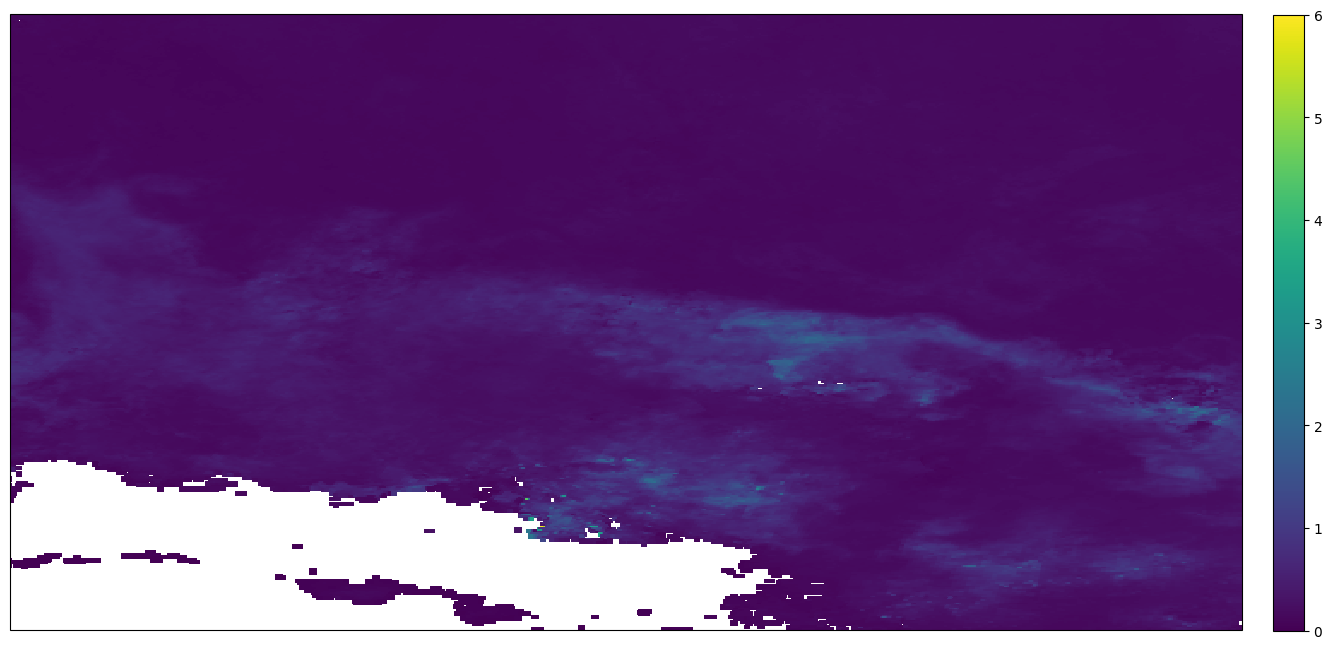

In [7]:
#assign projection type
crs0 = ccrs.PlateCarree()
#crs20 = ccrs.PlateCarree(central_longitude=80)

#create figure object
fig = plt.figure(figsize = (20,8))

#RECCAP regions panel
ax = fig.add_subplot(111, projection = crs0)

#Colormap specification
color = cmocean.cm.haline

# plot = da_chla.pcolor(cmap = color, transform = crs0,
#                       x = 'lon', y = 'lat', vmin = 0, vmax = 6, add_colorbar = True) 

plot = plt.pcolor(da_chla['lon'],da_chla['lat'],da_chla,
                 vmin = 0,vmax = 6) 

cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
cbar.ax.tick_params(labelsize=tick_size)
cbar.set_label('Chla', size=axis_size)

gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')

## Argo float loading code 

Not using this now, but keeping in the notebook in case you want to add trajectories or something

In [25]:
pdf = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv')
# pdf = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv') #for stevie

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_68651/518615070.py:1: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  pdf = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv')


In [26]:
#convert to datetime
pdf['DATE'] = pd.to_datetime(pdf['DATE'],format = 'mixed')
pdf = pdf.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon (I found one cycle on a float that was causing these errors)

#fix lat lon values with '--' (replace with nan) (no longer needed since I found the problem float)
# pdf['LATITUDE'] = pd.to_numeric(pdf['LATITUDE'], errors='coerce')
# pdf['LONGITUDE'] = pd.to_numeric(pdf['LONGITUDE'], errors='coerce')


In [27]:
#create season columns
pdf["year"] = pdf["DATE"].dt.year.astype("Int64")
pdf["month"] = pdf["DATE"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

pdf["season"] = pdf.apply(assign_season, axis=1)

In [28]:
# define function for calculating SA, CT, potential dens, in-situ dens
def calc_phys_vars(df):
        
    # Columns needed
    cols = ['PSAL_ADJUSTED','TEMP_ADJUSTED' ,'PRES_ADJUSTED', 'LATITUDE', 'LONGITUDE']
    
    # only do calculation on good qc T and S data - create nan values where not good data
    qc_flags = [1, 2, 8]
    mask_qc = df['PSAL_ADJUSTED_QC'].isin(qc_flags) & df['TEMP_ADJUSTED_QC'].isin(qc_flags)
    df['PSAL_ADJUSTED'] = df['PSAL_ADJUSTED'].where(mask_qc)
    df['TEMP_ADJUSTED'] = df['TEMP_ADJUSTED'].where(mask_qc)    
    
    # mask valid (non-null) rows
    mask = df[cols].notnull().all(axis=1)
    
    # initialize outputs as NaN
    SA = np.full(len(df), np.nan)
    CT = np.full(len(df), np.nan)
    rho = np.full(len(df), np.nan)
    sigma0 = np.full(len(df), np.nan)
    
    # extract numeric arrays for valid rows
    SP = df.loc[mask, 'PSAL_ADJUSTED'].astype(float).to_numpy()
    PT = df.loc[mask, 'TEMP_ADJUSTED'].astype(float).to_numpy()
    pres = df.loc[mask, 'PRES_ADJUSTED'].astype(float).to_numpy()
    LAT = df.loc[mask, 'LATITUDE'].astype(float).to_numpy()
    LON = df.loc[mask, 'LONGITUDE'].astype(float).to_numpy()
    
    # calculate variables using gsw
    SA_valid = gsw.SA_from_SP(SP=SP, p=pres, lon=LON, lat=LAT)
    CT_valid = gsw.CT_from_t(SA=SA_valid, t=PT, p=pres)
    rho_valid = gsw.rho(SA=SA_valid, CT=CT_valid, p=pres)
    sigma0_valid = gsw.sigma0(SA=SA_valid, CT=CT_valid)
    
    # store back into full-length arrays
    SA[mask] = SA_valid
    CT[mask] = CT_valid
    rho[mask] = rho_valid
    sigma0[mask] = sigma0_valid
    
    # sdd results to the dataframe
    df = df.copy()
    df['SA'] = SA
    df['CT'] = CT
    df['rho'] = rho
    df['sigma0'] = sigma0
    
    return df

pdf = calc_phys_vars(pdf)

In [29]:
#function for calculating MLD
#0.03 kg/m3 threshold

def calc_mlp_density(df_profile, delta_sigma=0.03):
    #calc MLD for a single profile using density threshold
    df_profile = df_profile.sort_values('PRES_ADJUSTED')

    # get SA, CT, and potential density values
    SA = df_profile['SA']
    CT = df_profile['CT']
    sigma0 = df_profile['sigma0']

    sigma_surface = sigma0.iloc[0]
    d_sigma = sigma0 - sigma_surface

    # find first depth where density difference exceeds threshold
    idx = np.argmax(d_sigma > delta_sigma)
    if d_sigma.iloc[idx] <= delta_sigma:
        return np.nan  # no threshold reached
    return df_profile['PRES_ADJUSTED'].iloc[idx]

mld = (pdf.groupby(['WMOID', 'CYCLE_NUMBER']).apply(calc_mlp_density).reset_index(name='MLP'))
pdf = pdf.merge(mld, on=['WMOID', 'CYCLE_NUMBER'], how='left')


/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_68651/4100982497.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mld = (pdf.groupby(['WMOID', 'CYCLE_NUMBER']).apply(calc_mlp_density).reset_index(name='MLP'))


In [30]:
#function for QC-ing on a column by column basis
def basic_qc(df,varname):
    # replace bad qc values for each column with nan
    df_out = df.copy()
    qc_flags = [1, 2, 8]
    mask_qc = df_out[f'{varname}_ADJUSTED_QC'].isin(qc_flags)
    df_out[f'{varname}_ADJUSTED'] = df_out[f'{varname}_ADJUSTED'].where(mask_qc)
    return df_out

#or subset all columns where QC flags are true
def subset_qc(df,varname):
    qc_flags = [1,2,8]
    df = df[df[f'{varname}_ADJUSTED_QC'].isin(qc_flags)]
    return df

pdf_clean = basic_qc(pdf, 'CHLA')

In [31]:
# Condition 1: July-Dec 2014
cond1 = (pdf['year'] == 2014) & (pdf['month'] >= 7)

# Condition 2: Jan-June 2015
cond2 = (pdf['year'] == 2015) & (pdf['month'] <= 6)

# Combine them with "OR" (|)
subset_df = pdf[cond1 | cond2]
subset_df['month']

423       1
424       1
425       1
426       1
427       1
         ..
472003    6
472004    6
472005    6
472006    6
472007    6
Name: month, Length: 68573, dtype: Int64

In [40]:
# sat_oct = xr.open_dataset('/Users/steviewalker/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141001_20141031.L3m.MO.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(142,172),
#                                lat = slice(-52,-70))
# sat_nov = xr.open_dataset('/Users/steviewalker/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141101_20141130.L3m.MO.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(142,172),
#                                lat = slice(-52,-70))
# sat_dec = xr.open_dataset('/Users/steviewalker/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141201_20141231.L3m.MO.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(142,172),
#                                lat = slice(-52,-70))

# da_chla = xu.fmax(sat_nov,sat_dec)
# sat_szn1 = xr.open_dataset('/Users/steviewalker/Documents/Bloom_Raiders/Data/satellite_data/AQUA_MODIS.20140921_20141220.L3m.SNAU.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))
# sat_szn2 = xr.open_dataset('/Users/steviewalker/Documents/Bloom_Raiders/Data/satellite_data/AQUA_MODIS.20141221_20150320.L3m.SNWI.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))

# sat_szn1 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141101_20141130.L3m.November_2014.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))
# sat_szn2 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141201_20141231.L3m.December_2014.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))
# sat_szn3 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150101_20150131.L3m.January_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))
# sat_szn4 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150201_20150228.L3m.February_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))
# sat_szn5 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150301_20150331.L3m.March_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))
# sat_szn6 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150401_20150430.L3m.April_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
#                                lat = slice(-55,-70))

# da_chla = (sat_szn1, sat_szn2, sat_szn3, sat_szn4, sat_szn5, sat_szn6)

sat_szn1 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20140921_20141220.L3m.SNAU.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
                               lat = slice(-55,-70))
sat_szn2 = xr.open_dataset('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141221_20150320.L3m.SNWI.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),
                               lat = slice(-55,-70))

da_chla = (sat_szn1, sat_szn2)
# da_chla = sat_ds['chlor_a'].sel(lon = slice(142,172),
#                                lat = slice(-52,-70))
# da_chla

In [19]:
files = [('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141101_20141130.L3m.November_2014.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),lat = slice(-55,-70)), ('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20141201_20141231.L3m.December_2014.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),lat = slice(-55,-70)), ('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150101_20150131.L3m.January_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),lat = slice(-55,-70)), ('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150201_20150228.L3m.February_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),lat = slice(-55,-70)), ('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150301_20150331.L3m.March_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),lat = slice(-55,-70)), ('/Users/lilah/Documents/IBIS_Project/Data/satellite_data/AQUA_MODIS.20150401_20150430.L3m.April_2015.CHL.chlor_a.4km.nc')['chlor_a'].sel(lon = slice(145,170),lat = slice(-55,-70))]




<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning:

TypeError: string indices must be integers, not 'str'

TypeError: tuple indices must be integers or slices, not str

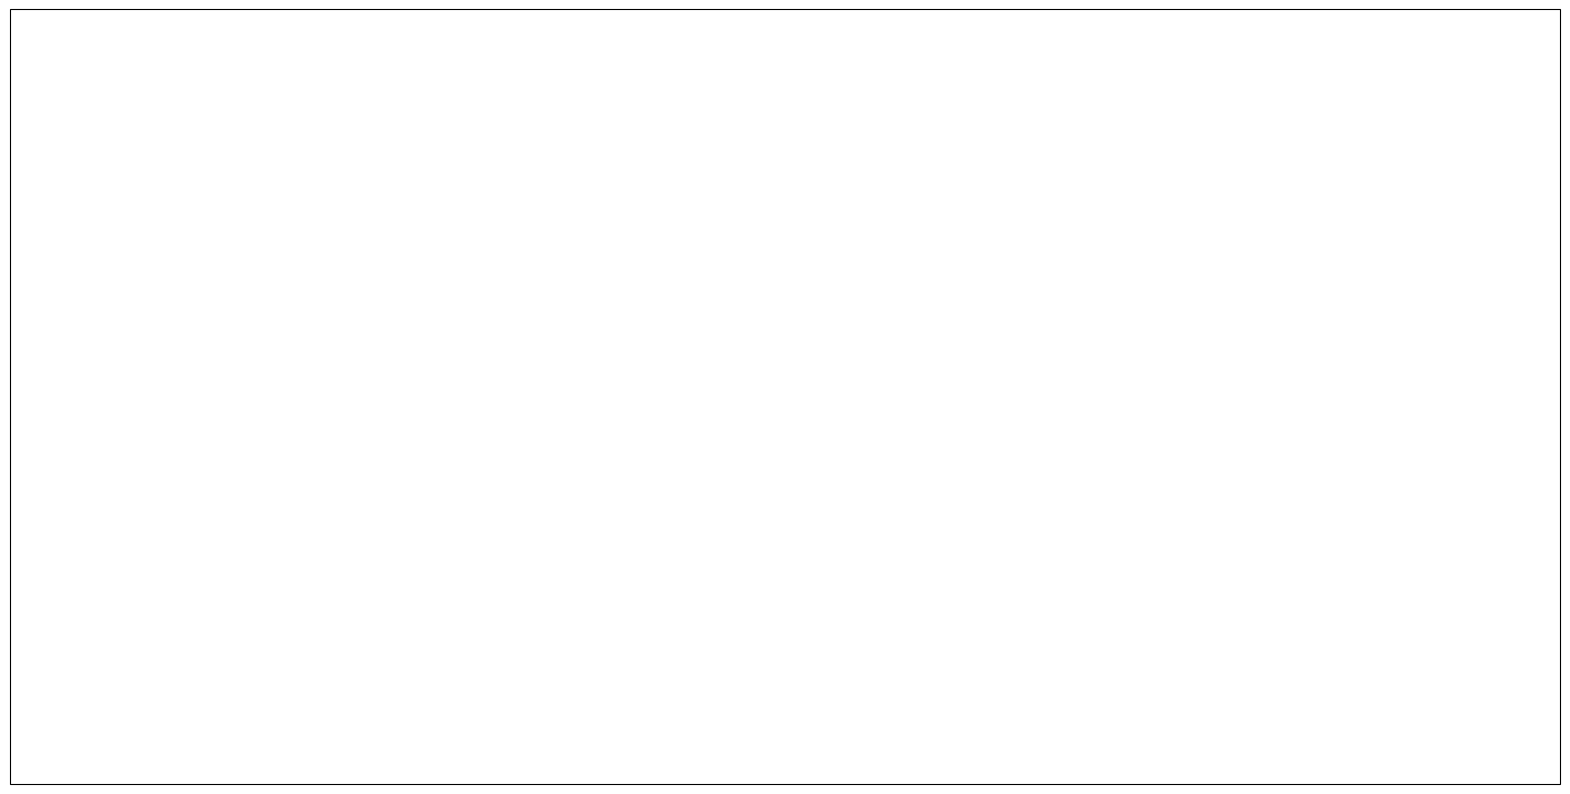

In [41]:
def traj_yr_wmo(df, wmo_val): # Renamed argument to wmo_val to avoid confusion
    
    # 1. Filter the dataframe to ONLY the specific float first
    # Replace 'WMOID' with the actual string name of your column
    df_single = df[df['WMOID'] == wmo_val].copy() 
    
    fig = plt.figure(figsize=(20, 20))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # add satellite data 
    plot = plt.pcolor(da_chla['lon'],da_chla['lat'],da_chla,cmap = 'viridis',
                     norm=LogNorm(vmin=0.1, vmax=6))
    # plot = plt.pcolor(da_chla['lon'],da_chla['lat'],da_chla,cmap = 'viridis',
    #                  norm=LogNorm(vmin=0.1, vmax=6))
    
    # add basemap features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN)
    
    # 2. Use the SUBSET (df_single) for your calculations, not the original 'df'
    # This ensures ONLY the specified WMOID data is processed
    df_chla = (df_single.loc[df_single.groupby(['WMOID', 'CYCLE_NUMBER'])['CHLA_ADJUSTED'].idxmax()])
    #get chla at 5 dbar in all profiles
    # df_chla = (df_single.loc[df_single.groupby(['WMOID', 'CYCLE_NUMBER'])['PRES_ADJUSTED'].apply(lambda x: (x - 10).abs().idxmin())])

    
    # 3. Use the filtered df_chla for the scatter plot
    sc = ax.scatter(df_chla['LONGITUDE'], 
                    df_chla['LATITUDE'],
                    c=df_chla['CHLA_ADJUSTED'], 
                    cmap='viridis',
                    s=250,
                    transform=ccrs.PlateCarree(),
                    norm=LogNorm(vmin=0.1, vmax=8), 
                    edgecolor='black', 
                    linewidth=1)

     # labels
    lon_ticks = np.arange(145, 171, 5)
    lat_ticks = np.arange(-70, -55, 2)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(axis='both', pad =14, labelsize=30)
    
    ax.set_title(f'Float 5904104 Trajectory', fontsize=60, pad = 25)
    ax.set_xlabel('', fontsize=38)
    ax.set_ylabel('', fontsize=38)
   
    cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05,shrink=0.45)
    cbar.set_label('Log Chl-a (mg m$^{-3}$)', fontsize = 35)
    cbar.locator = LogLocator(base=10, subs=(1, 2, 5))
    cbar.formatter = FormatStrFormatter("%.1f")
    cbar.ax.tick_params(labelsize=35, pad = 14) 
    cbar.update_ticks()

        
    plt.tight_layout()
    plt.show()

    # fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_traj_4_2014-15.svg', dpi = 300, bbox_inches='tight')
            

traj_yr_wmo(df = subset_df, wmo_val= 5904104)

